In [1]:
import pandas as pd

In [53]:
df=pd.read_csv("Book1.csv")
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [5]:
df.isna().sum()

cgpa       0
package    0
dtype: int64

In [7]:
df.shape

(200, 2)

want package based on cgpa so x=cgpa, y=package

In [27]:
x=df.iloc[:,0:1]    #x=df[['cgpa']]
y=df.iloc[:,-1]    #y=df['package']

In [28]:
x

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [29]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 1)
(40, 1)
(160,)
(40,)


In [31]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
print(y_pred)

[2.9383335  4.36894346 3.18258398 1.89736121 3.49662031 3.35123312
 2.76968435 2.94996447 3.07208971 3.94441286 3.57222165 2.94996447
 2.75805338 2.64755911 3.67108494 3.2174769  3.97930579 2.90925606
 2.19395108 3.31052471 4.29915761 2.8918096  1.87409926 2.30444534
 3.62456104 2.12998071 3.9269664  2.36841571 1.5716939  2.06601035
 2.31026083 3.6885314  3.5024358  3.03719679 2.57195777 2.39167766
 3.170953   3.82228762 3.15932203 2.94414898]


In [32]:
a=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
a

,Actual,Predicted
58,3.09,2.938333
40,4.02,4.368943
34,3.42,3.182584
102,1.37,1.897361
184,3.14,3.496620
198,3.96,3.351233
95,2.79,2.769684
4,3.57,2.949964
29,3.49,3.072090
168,3.52,3.944413


In [33]:
print("coefficient",lr.coef_)
print("Intercept",lr.intercept_)

coefficient [0.58154877]
Intercept -1.0859839580358033


In [35]:
from sklearn import metrics
print("MAE",metrics.mean_absolute_error(y_test,y_pred))
print("MSE",metrics.mean_squared_error(y_test,y_pred))
print("R2 score",metrics.r2_score(y_test,y_pred))

MAE 0.29931188593316804
MSE 0.1370062519255722
R2 score 0.7283345498058083


In [45]:
from sklearn import metrics
random_state=42
results = []
for i in range(0,random_state):
    mae=metrics.mean_absolute_error(y_test,y_pred)
    mse=metrics.mean_squared_error(y_test,y_pred)
    r2=metrics.r2_score(y_test,y_pred)

results.append({'random_state': i, 'mae': mae, 'mse': mse, 'r2': r2})

df = pd.DataFrame(results)
min_error = df.loc[df['mae'].min()]
print("Best random_state by MAE:")
print(min_error)


KeyError: 0.29931188593316804

In [46]:
import matplotlib.pyplot as plt

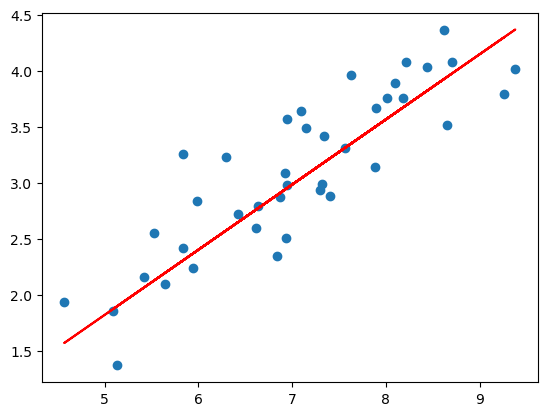

In [48]:
plt.scatter(x_test,y_test)
plt.plot(x_test,y_pred,color="red")
plt.show()

In [49]:
import seaborn as sns

<Axes: xlabel='cgpa', ylabel='package'>

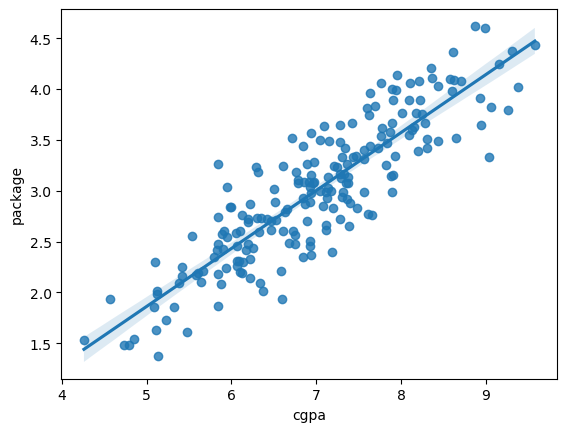

In [56]:
sns.regplot(data=df,x="cgpa",y="package")

In [55]:
ypred=lr.predict([[6.5]])
print(ypred)

[2.69408301]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## multiple linear regression

In [89]:
df=pd.read_csv("car data.csv")

In [90]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [91]:
print(df['Car_Name'].nunique())

98


- remove car name
- convert year to age and then remove year
- get dummiess(drop first) : fuel type, seller type, transmission

In [93]:
y.shape

(301,)

In [94]:
df.drop('Car_Name',axis=1,inplace=True)

In [95]:
df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [96]:
df['Age']=2026-df['Year']
df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [101]:
df.drop(['Year'],axis=1,inplace=True)

In [102]:
df=pd.get_dummies(data=df,drop_first=True)
df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


In [103]:
df.shape

(301, 9)

In [104]:
y=df['Selling_Price']
x=df.drop('Selling_Price',axis=1)

In [105]:
print(x.shape)

(301, 8)


In [106]:
print(y.shape)

(301,)


In [109]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(240, 8)
(61, 8)
(240,)
(61,)


In [111]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
print(y_pred)

[ 7.86273200e+00  2.96828691e+00 -5.90305107e-01  4.21335952e+00
  4.83175534e-01  5.82053813e+00  1.95679784e+00  2.55809661e+00
  7.70870833e+00  9.78692192e-01  8.13484343e+00  3.51207180e+00
  4.90669281e+00  4.63905587e+00 -2.15886643e+00  3.13874624e+00
  7.98256903e+00  6.75937638e+00  6.90426580e+00  8.01440587e+00
  4.31168610e+00  4.00336757e+00  1.13040883e+01  8.07939189e+00
  9.54399823e+00  3.52133877e+00  3.80609808e+00  1.06074722e+00
 -6.01732475e-01 -6.19712043e-01  1.32818516e-03 -1.28500691e+00
  4.28533553e+00  2.06769487e+01  1.87563232e+01  4.27292100e+00
  3.48602852e+00  1.66739677e+00 -4.38707073e-02  5.78536030e+00
  8.03940428e+00  9.88367483e+00  4.09684249e-01  6.07997517e+00
  5.88038915e+00  4.32745252e+00  7.37534505e+00  5.86171335e+00
  8.21129880e+00  1.65455816e+00  3.83033706e+00  1.75047060e+00
  2.51406796e+00  4.20404709e+00  1.48991546e+00 -3.44185843e+00
  2.04806215e+01  6.62503544e-01  5.40027412e+00  5.65856241e+00
  6.47876234e-01]


In [112]:
a=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
a

,Actual,Predicted
285,7.40,7.862732
248,4.00,2.968287
150,0.50,-0.590305
217,3.15,4.213360
107,1.25,0.483176
...,...,...
62,18.75,20.480622
154,0.50,0.662504
218,6.45,5.400274
286,5.65,5.658562


In [113]:
print("coefficient",lr.coef_)
print("Intercept",lr.intercept_)

coefficient [ 4.37233976e-01 -5.30613944e-06  3.45912849e-01 -4.13270098e-01
  2.23050770e+00  4.58549217e-01 -1.20927814e+00 -1.87014327e+00]
Intercept 7.900300130264206


In [114]:
from sklearn import metrics
print("MAE",metrics.mean_absolute_error(y_test,y_pred))
print("MSE",metrics.mean_squared_error(y_test,y_pred))
print("R2 score",metrics.r2_score(y_test,y_pred))

MAE 1.0998575552990955
MSE 2.9823848618597513
R2 score 0.8625260513315252
